In [1]:
!pip install openpyxl


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel(
    "oasis_longitudinal_demographics.xlsx"
)

df.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1986.550000,0.696106,0.883440
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004.479526,0.681062,0.875539
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678.290000,0.736336,1.045710
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1737.620000,0.713402,1.010000
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1697.911134,0.701236,1.033623


In [4]:
df.shape

(373, 15)

In [5]:
df["Subject ID"].nunique()

150

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    object 
 1   MRI ID      373 non-null    object 
 2   Group       373 non-null    object 
 3   Visit       373 non-null    int64  
 4   MR Delay    373 non-null    int64  
 5   M/F         373 non-null    object 
 6   Hand        373 non-null    object 
 7   Age         373 non-null    int64  
 8   EDUC        373 non-null    int64  
 9   SES         354 non-null    float64
 10  MMSE        371 non-null    float64
 11  CDR         373 non-null    float64
 12  eTIV        373 non-null    float64
 13  nWBV        373 non-null    float64
 14  ASF         373 non-null    float64
dtypes: float64(6), int64(4), object(5)
memory usage: 43.8+ KB


In [7]:
df.describe()

,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
count,373.000000,373.000000,373.000000,373.000000,354.000000,371.000000,373.000000,373.000000,373.000000,373.000000
mean,1.882038,595.104558,77.013405,14.597855,2.460452,27.342318,0.290885,1488.121584,0.729556,1.195460
std,0.922843,635.485118,7.640957,2.876339,1.134005,3.683244,0.374557,176.135956,0.037141,0.138105
min,1.000000,0.000000,60.000000,6.000000,1.000000,4.000000,0.000000,1105.652499,0.644399,0.875539
25%,1.000000,0.000000,71.000000,12.000000,2.000000,27.000000,0.000000,1357.330000,0.700191,1.098979
50%,2.000000,552.000000,77.000000,15.000000,2.000000,29.000000,0.000000,1470.041312,0.728789,1.193844
75%,2.000000,873.000000,82.000000,16.000000,3.000000,30.000000,0.500000,1596.936793,0.755669,1.292980
max,5.000000,2639.000000,98.000000,23.000000,5.000000,30.000000,2.000000,2004.479526,0.836842,1.587298


In [8]:
df['Visit'].head(20)

0     1
1     2
2     1
3     2
4     3
5     1
6     2
7     1
8     2
9     3
10    1
11    3
12    4
13    1
14    2
15    1
16    2
17    1
18    2
19    1
Name: Visit, dtype: int64

In [9]:
df["Visit"].isnull().sum()

np.int64(0)

In [10]:
df[["Subject ID", "MRI ID", "Visit", "MR Delay"]].head(20)

,Subject ID,MRI ID,Visit,MR Delay
0,OAS2_0001,OAS2_0001_MR1,1,0
1,OAS2_0001,OAS2_0001_MR2,2,457
2,OAS2_0002,OAS2_0002_MR1,1,0
3,OAS2_0002,OAS2_0002_MR2,2,560
4,OAS2_0002,OAS2_0002_MR3,3,1895
5,OAS2_0004,OAS2_0004_MR1,1,0
6,OAS2_0004,OAS2_0004_MR2,2,538
7,OAS2_0005,OAS2_0005_MR1,1,0
8,OAS2_0005,OAS2_0005_MR2,2,1010
9,OAS2_0005,OAS2_0005_MR3,3,1603


In [11]:
df["Subject ID"].nunique()

150

In [12]:
df.columns

Index(['Subject ID', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'M/F', 'Hand',
       'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF'],
      dtype='object')

In [13]:
df.isnull().sum()

Subject ID     0
MRI ID         0
Group          0
Visit          0
MR Delay       0
M/F            0
Hand           0
Age            0
EDUC           0
SES           19
MMSE           2
CDR            0
eTIV           0
nWBV           0
ASF            0
dtype: int64

In [14]:
df["Group"].value_counts()


Group
Nondemented    190
Demented       146
Converted       37
Name: count, dtype: int64

In [15]:
df["Group"].value_counts(normalize=True) * 100

Group
Nondemented    50.938338
Demented       39.142091
Converted       9.919571
Name: proportion, dtype: float64

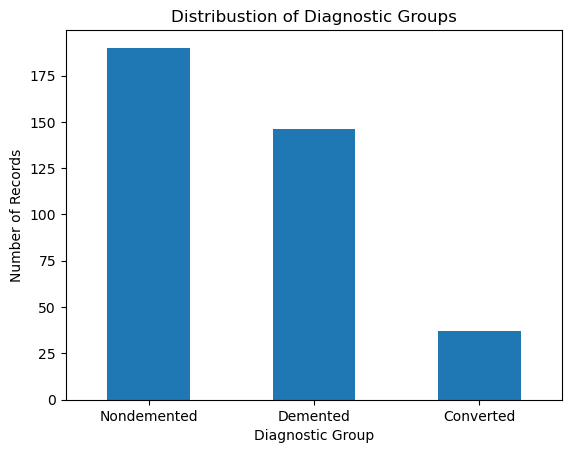

In [16]:
import matplotlib.pyplot as plt

df['Group'].value_counts().plot(kind='bar')

plt.title('Distribustion of Diagnostic Groups')
plt.xlabel('Diagnostic Group')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()

In [17]:
df[["Subject ID", "Visit", "MR Delay", "Group", "Age", "MMSE", "CDR"]].head(20)

,Subject ID,Visit,MR Delay,Group,Age,MMSE,CDR
0,OAS2_0001,1,0,Nondemented,87,27.0,0.0
1,OAS2_0001,2,457,Nondemented,88,30.0,0.0
2,OAS2_0002,1,0,Demented,75,23.0,0.5
3,OAS2_0002,2,560,Demented,76,28.0,0.5
4,OAS2_0002,3,1895,Demented,80,22.0,0.5
5,OAS2_0004,1,0,Nondemented,88,28.0,0.0
6,OAS2_0004,2,538,Nondemented,90,27.0,0.0
7,OAS2_0005,1,0,Nondemented,80,28.0,0.0
8,OAS2_0005,2,1010,Nondemented,83,29.0,0.5
9,OAS2_0005,3,1603,Nondemented,85,30.0,0.0


In [18]:
visits_per_patient = df.groupby("Subject ID").size()

visits_per_patient.value_counts().sort_index()

2    94
3    43
4     9
5     4
Name: count, dtype: int64

In [19]:
visits_per_patient.describe()

count    150.000000
mean       2.486667
std        0.730327
min        2.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        5.000000
dtype: float64

In [20]:
converted = df[df["Group"] == "Converted"]

converted[
    ["Subject ID", "Visit", "MR Delay", "Age", "MMSE", "CDR"]
].head(30)

,Subject ID,Visit,MR Delay,Age,MMSE,CDR
33,OAS2_0018,1,0,87,30.0,0.0
34,OAS2_0018,3,489,88,29.0,0.0
35,OAS2_0018,4,1933,92,27.0,0.5
36,OAS2_0020,1,0,80,29.0,0.0
37,OAS2_0020,2,756,82,28.0,0.5
38,OAS2_0020,3,1563,84,26.0,0.5
57,OAS2_0031,1,0,86,30.0,0.0
58,OAS2_0031,2,446,88,30.0,0.0
59,OAS2_0031,3,1588,91,28.0,0.5
81,OAS2_0041,1,0,71,27.0,0.0


In [21]:
converted["Subject ID"].nunique()

14

In [22]:
converted.groupby("Subject ID")[
    ["Visit", "MR Delay", "Age", "MMSE", "CDR"]
].first().head(10)

,Visit,MR Delay,Age,MMSE,CDR
Subject ID,,,,,
OAS2_0018,1,0,87,30.0,0.0
OAS2_0020,1,0,80,29.0,0.0
OAS2_0031,1,0,86,30.0,0.0
OAS2_0041,1,0,71,27.0,0.0
OAS2_0054,1,0,85,29.0,0.0
OAS2_0092,1,0,83,28.0,0.0
OAS2_0103,1,0,69,30.0,0.0
OAS2_0118,1,0,67,30.0,0.0
OAS2_0127,1,0,79,29.0,0.0


In [23]:
missing = df.isnull().sum()

missing[missing > 0]

SES     19
MMSE     2
dtype: int64

In [24]:
(df.isnull().mean() * 100).sort_values(ascending=False)

SES           5.093834
MMSE          0.536193
Subject ID    0.000000
MRI ID        0.000000
Group         0.000000
Visit         0.000000
MR Delay      0.000000
M/F           0.000000
Hand          0.000000
Age           0.000000
EDUC          0.000000
CDR           0.000000
eTIV          0.000000
nWBV          0.000000
ASF           0.000000
dtype: float64

In [25]:
categorical_columns = ["Group", "M/F", "Hand"]

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


Group
Group
Nondemented    190
Demented       146
Converted       37
Name: count, dtype: int64

M/F
M/F
F    213
M    160
Name: count, dtype: int64

Hand
Hand
R    373
Name: count, dtype: int64


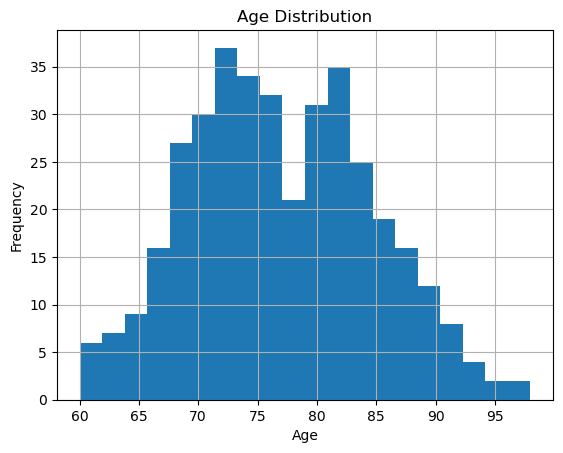

In [26]:
df["Age"].hist(bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

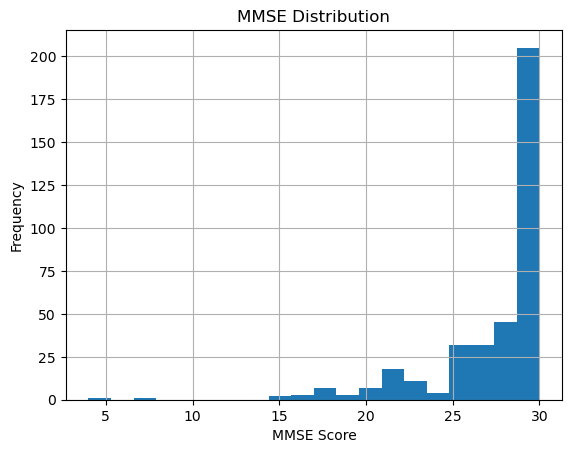

In [27]:
df["MMSE"].hist(bins=20)

plt.title("MMSE Distribution")
plt.xlabel("MMSE Score")
plt.ylabel("Frequency")
plt.show()

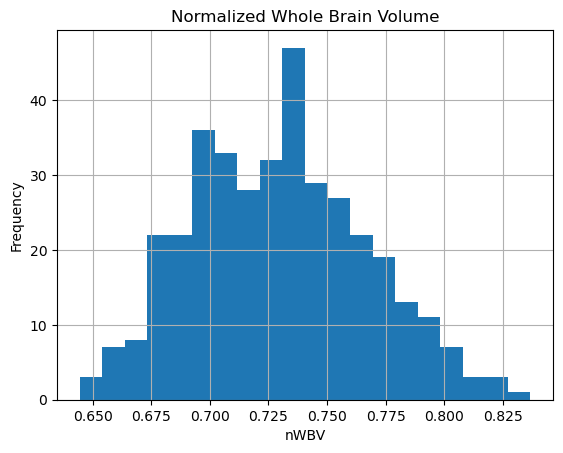

In [28]:
df["nWBV"].hist(bins=20)

plt.title("Normalized Whole Brain Volume")
plt.xlabel("nWBV")
plt.ylabel("Frequency")
plt.show()

In [29]:
df.groupby("Group")["MMSE"].describe()

,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
Converted,37.0,28.675676,1.564432,24.0,28.0,29.0,30.0,30.0
Demented,144.0,24.513889,4.497064,4.0,22.0,26.0,28.0,30.0
Nondemented,190.0,29.226316,0.882722,26.0,29.0,29.0,30.0,30.0


In [30]:
df.groupby("Group")["Age"].mean()

Group
Converted      79.756757
Demented       76.260274
Nondemented    77.057895
Name: Age, dtype: float64

In [31]:
df.groupby("Group")["nWBV"].mean()

Group
Converted      0.723734
Demented       0.716303
Nondemented    0.740873
Name: nWBV, dtype: float64

In [32]:
df.groupby("Group")["CDR"].mean()

Group
Converted      0.256757
Demented       0.671233
Nondemented    0.005263
Name: CDR, dtype: float64

In [33]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

In [34]:
correlation = numeric_df.corr()

correlation

,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
Visit,1.000000,0.920009,0.183213,0.024615,-0.051622,-0.029078,0.002325,0.117423,-0.125826,-0.120439
MR Delay,0.920009,1.000000,0.205357,0.051630,-0.030813,0.065844,-0.062915,0.119641,-0.104737,-0.123615
Age,0.183213,0.205357,1.000000,-0.027886,-0.046857,0.055612,-0.026257,0.042401,-0.518546,-0.034845
EDUC,0.024615,0.051630,-0.027886,1.000000,-0.722647,0.194884,-0.153121,0.257042,-0.012300,-0.241696
SES,-0.051622,-0.030813,-0.046857,-0.722647,1.000000,-0.149219,0.076160,-0.261582,0.089956,0.255448
MMSE,-0.029078,0.065844,0.055612,0.194884,-0.149219,1.000000,-0.686519,-0.032088,0.341912,0.040145
CDR,0.002325,-0.062915,-0.026257,-0.153121,0.076160,-0.686519,1.000000,0.022863,-0.344873,-0.029426
eTIV,0.117423,0.119641,0.042401,0.257042,-0.261582,-0.032088,0.022863,1.000000,-0.209875,-0.988868
nWBV,-0.125826,-0.104737,-0.518546,-0.012300,0.089956,0.341912,-0.344873,-0.209875,1.000000,0.213073
ASF,-0.120439,-0.123615,-0.034845,-0.241696,0.255448,0.040145,-0.029426,-0.988868,0.213073,1.000000


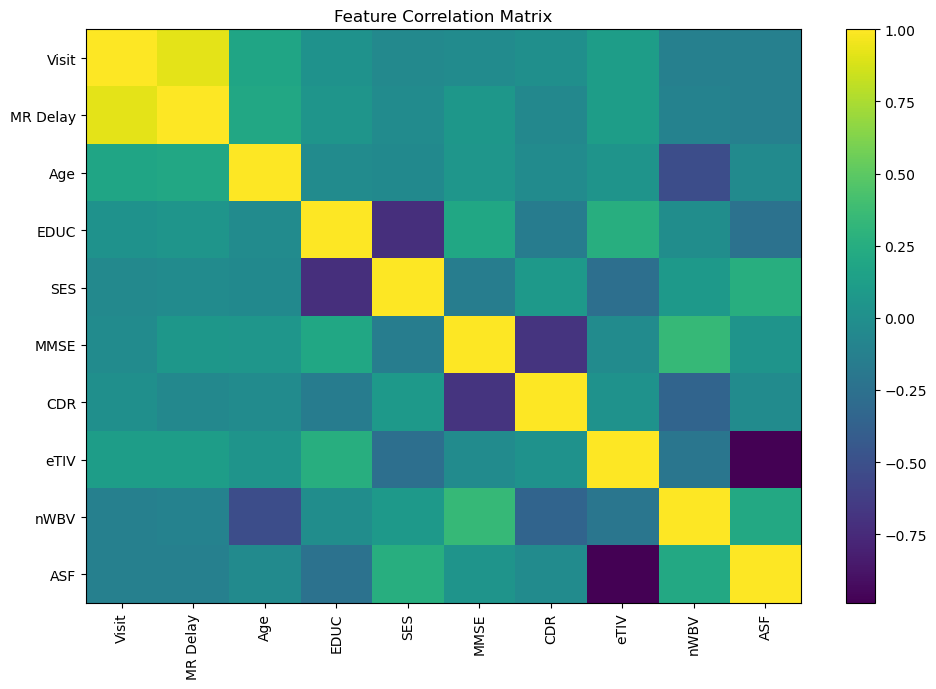

In [35]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [36]:
pd.crosstab(df["CDR"], df["Group"])

Group,Converted,Demented,Nondemented
CDR,,,
0.0,18,0,188
0.5,19,102,2
1.0,0,41,0
2.0,0,3,0


In [37]:
df.groupby("Group")[["Age", "MMSE", "CDR", "nWBV", "eTIV", "ASF"]].mean().round(3)

,Age,MMSE,CDR,nWBV,eTIV,ASF
Group,,,,,,
Converted,79.757,28.676,0.257,0.724,1459.347,1.212
Demented,76.260,24.514,0.671,0.716,1485.848,1.197
Nondemented,77.058,29.226,0.005,0.741,1495.472,1.191


* Observation: The Demented group has a lower average MMSE score and lower normalized whole-brain volume (nWBV) compared with the Nondemented group. The Demented group also has a substantially higher average CDR. The Converted group generally lies between the Nondemented and Demented groups for several of these measures. CDR appears particularly strongly associated with the diagnostic group and therefore needs to be investigated for possible target leakage before model training.

In [38]:
pd.crosstab(df["CDR"], df["Group"])

Group,Converted,Demented,Nondemented
CDR,,,
0.0,18,0,188
0.5,19,102,2
1.0,0,41,0
2.0,0,3,0


In [39]:
converted_df = df[df["Group"] == "Converted"]

converted_df[
    ["Subject ID", "Visit", "MR Delay", "CDR"]
].sort_values(["Subject ID", "Visit"])

,Subject ID,Visit,MR Delay,CDR
33,OAS2_0018,1,0,0.0
34,OAS2_0018,3,489,0.0
35,OAS2_0018,4,1933,0.5
36,OAS2_0020,1,0,0.0
37,OAS2_0020,2,756,0.5
38,OAS2_0020,3,1563,0.5
57,OAS2_0031,1,0,0.0
58,OAS2_0031,2,446,0.0
59,OAS2_0031,3,1588,0.5
81,OAS2_0041,1,0,0.0


In [40]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation = numeric_df.corr()

correlation.round(2)

,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
Visit,1.00,0.92,0.18,0.02,-0.05,-0.03,0.00,0.12,-0.13,-0.12
MR Delay,0.92,1.00,0.21,0.05,-0.03,0.07,-0.06,0.12,-0.10,-0.12
Age,0.18,0.21,1.00,-0.03,-0.05,0.06,-0.03,0.04,-0.52,-0.03
EDUC,0.02,0.05,-0.03,1.00,-0.72,0.19,-0.15,0.26,-0.01,-0.24
SES,-0.05,-0.03,-0.05,-0.72,1.00,-0.15,0.08,-0.26,0.09,0.26
MMSE,-0.03,0.07,0.06,0.19,-0.15,1.00,-0.69,-0.03,0.34,0.04
CDR,0.00,-0.06,-0.03,-0.15,0.08,-0.69,1.00,0.02,-0.34,-0.03
eTIV,0.12,0.12,0.04,0.26,-0.26,-0.03,0.02,1.00,-0.21,-0.99
nWBV,-0.13,-0.10,-0.52,-0.01,0.09,0.34,-0.34,-0.21,1.00,0.21
ASF,-0.12,-0.12,-0.03,-0.24,0.26,0.04,-0.03,-0.99,0.21,1.00


In [41]:
df_v1 = df[df["Visit"] == 1].copy()

df_v1.shape

(150, 15)

In [42]:
df_v1["Subject ID"].nunique()

150

In [43]:
df_v1["Group"].value_counts()

Group
Nondemented    72
Demented       64
Converted      14
Name: count, dtype: int64

In [49]:
df_v1[df_v1["Group"] == "Converted"][
    ["Subject ID", "Age", "MMSE", "CDR", "nWBV"]
    ]

,Subject ID,Age,MMSE,CDR,nWBV
33,OAS2_0018,87,30.0,0.0,0.715094
36,OAS2_0020,80,29.0,0.0,0.693174
57,OAS2_0031,86,30.0,0.0,0.718065
81,OAS2_0041,71,27.0,0.0,0.771306
114,OAS2_0054,85,29.0,0.0,0.700956
194,OAS2_0092,83,28.0,0.0,0.747738
218,OAS2_0103,69,30.0,0.0,0.750452
245,OAS2_0118,67,30.0,0.0,0.794255
261,OAS2_0127,79,29.0,0.0,0.728789
271,OAS2_0131,65,30.0,0.5,0.753674


In [45]:
model_df = df_v1[
    df_v1["Group"].isin(["Nondemented", "Demented"])
].copy()

In [46]:
model_df.shape

(136, 15)

In [50]:
model_df["Group"].value_counts()

Group
Nondemented    72
Demented       64
Name: count, dtype: int64

In [51]:
df_v1.shape
df_v1["Subject ID"].nunique()
df_v1["Group"].value_counts()

Group
Nondemented    72
Demented       64
Converted      14
Name: count, dtype: int64

In [52]:
features = [
    "Age",
    "M/F",
    "EDUC",
    "SES",
    "MMSE",
    "eTIV",
    "nWBV"
]

In [53]:
X = model_df[features].copy()

y = model_df["Group"].map({
    "Nondemented": 0,
    "Demented": 1
})

In [54]:
print(X.shape)
print(y.shape)

X.head()

(136, 7)
(136,)


,Age,M/F,EDUC,SES,MMSE,eTIV,nWBV
0,87,M,14,2.0,27.0,1986.55,0.696106
2,75,M,12,NaN,23.0,1678.29,0.736336
5,88,F,18,3.0,28.0,1215.33,0.709512
7,80,M,12,4.0,28.0,1688.58,0.711502
10,71,M,16,NaN,28.0,1357.33,0.748085


In [55]:
y.value_counts()

Group
0    72
1    64
Name: count, dtype: int64

In [56]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 136 entries, 0 to 370
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     136 non-null    int64  
 1   M/F     136 non-null    object 
 2   EDUC    136 non-null    int64  
 3   SES     128 non-null    float64
 4   MMSE    136 non-null    float64
 5   eTIV    136 non-null    float64
 6   nWBV    136 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 8.5+ KB


In [60]:
X.isnull().sum()

Age     0
M/F     0
EDUC    0
SES     8
MMSE    0
eTIV    0
nWBV    0
dtype: int64

In [62]:
model_df.shape
model_df["Group"].value_counts()

X.head()

y.value_counts()

X.info()
X.isnull().mean()*100

<class 'pandas.core.frame.DataFrame'>
Index: 136 entries, 0 to 370
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     136 non-null    int64  
 1   M/F     136 non-null    object 
 2   EDUC    136 non-null    int64  
 3   SES     128 non-null    float64
 4   MMSE    136 non-null    float64
 5   eTIV    136 non-null    float64
 6   nWBV    136 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 8.5+ KB


Age     0.000000
M/F     0.000000
EDUC    0.000000
SES     5.882353
MMSE    0.000000
eTIV    0.000000
nWBV    0.000000
dtype: float64

In [63]:
from sklearn.model_selection import train_test_split

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [65]:
print("Training X:", X_train.shape)
print("Testing X:", X_test.shape)

print("\nTraining classes:")
print(y_train.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

Training X: (108, 7)
Testing X: (28, 7)

Training classes:
Group
0    57
1    51
Name: count, dtype: int64

Testing classes:
Group
0    15
1    13
Name: count, dtype: int64


In [66]:
X_train.isnull().sum()

Age     0
M/F     0
EDUC    0
SES     7
MMSE    0
eTIV    0
nWBV    0
dtype: int64

In [67]:
numeric_features = [
    "Age",
    "EDUC",
    "SES",
    "MMSE",
    "eTIV",
    "nWBV"
]

categorical_features = [
    "M/F"
]

In [68]:
numeric_features = [
    "Age",
    "EDUC",
    "SES",
    "MMSE",
    "eTIV",
    "nWBV"
]

categorical_features = [
    "M/F"
]

In [70]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [71]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [72]:
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [73]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [74]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [75]:
from sklearn.linear_model import LogisticRegression

In [76]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [77]:
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [78]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [79]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [80]:
scoring = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

In [81]:
logistic_cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [82]:
import numpy as np

for metric in scoring:
    scores = logistic_cv_results[f"test_{metric}"]
    print(
        metric,
        "mean:",
        round(scores.mean(), 3),
        "std:",
        round(scores.std(), 3)
    )

accuracy mean: 0.852 std: 0.045
precision mean: 0.933 std: 0.055
recall mean: 0.745 std: 0.1
f1 mean: 0.823 std: 0.06
roc_auc mean: 0.915 std: 0.053


In [83]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [84]:
y_pred_log = logistic_pipeline.predict(X_test)

In [85]:
y_prob_log = logistic_pipeline.predict_proba(X_test)[:, 1]

In [100]:
# logistic
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

Accuracy: 0.75
Precision: 0.8
Recall: 0.6153846153846154
F1: 0.6956521739130435
ROC-AUC: 0.7794871794871795


In [87]:
# Logistic Regression
print(confusion_matrix(y_test, y_pred_log))

[[13  2]
 [ 5  8]]


In [88]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.72      0.87      0.79        15
           1       0.80      0.62      0.70        13

    accuracy                           0.75        28
   macro avg       0.76      0.74      0.74        28
weighted avg       0.76      0.75      0.75        28



In [89]:
from sklearn.ensemble import RandomForestClassifier

In [90]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

In [91]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [92]:
rf_cv_results = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [93]:
for metric in scoring:
    scores = rf_cv_results[f"test_{metric}"]
    print(
        metric,
        "mean:",
        round(scores.mean(), 3),
        "std:",
        round(scores.std(), 3)
    )

accuracy mean: 0.861 std: 0.029
precision mean: 0.924 std: 0.069
recall mean: 0.784 std: 0.117
f1 mean: 0.838 std: 0.05
roc_auc mean: 0.906 std: 0.05


In [94]:
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [95]:
# Random Forest
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.75
Precision: 0.8
Recall: 0.6153846153846154
F1: 0.6956521739130435
ROC-AUC: 0.7923076923076923


In [96]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.75,0.8,0.615,0.696,0.779
1,Random Forest,0.75,0.8,0.615,0.696,0.792


In [97]:
# Random Forest
cm = confusion_matrix(y_test, y_pred_rf)

cm

array([[13,  2],
       [ 5,  8]])

In [98]:
import joblib

In [99]:
joblib.dump(
    rf_pipeline,
    "../model/neuropath_v1.pkl"
)

['../model/neuropath_v1.pkl']

In [101]:
print("Logistic Regression:")
print(confusion_matrix(y_test, y_pred_log))

print("\nRandom Forest:")
print(confusion_matrix(y_test, y_pred_rf))

Logistic Regression:
[[13  2]
 [ 5  8]]

Random Forest:
[[13  2]
 [ 5  8]]


In [102]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(3)

,Threshold,Accuracy,Precision,Recall,F1
0,0.30,0.571,0.526,0.769,0.625
1,0.35,0.607,0.556,0.769,0.645
2,0.40,0.643,0.600,0.692,0.643
3,0.45,0.679,0.643,0.692,0.667
4,0.50,0.750,0.800,0.615,0.696
5,0.55,0.750,0.800,0.615,0.696
6,0.60,0.786,0.889,0.615,0.727


In [103]:
from sklearn.model_selection import cross_val_predict

# Get out-of-fold probabilities using TRAINING DATA ONLY
y_train_prob_cv = cross_val_predict(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

In [104]:
thresholds = np.arange(0.20, 0.81, 0.05)

cv_threshold_results = []

for threshold in thresholds:

    y_pred_cv = (y_train_prob_cv >= threshold).astype(int)

    cv_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_train, y_pred_cv),
        "Precision": precision_score(y_train, y_pred_cv),
        "Recall": recall_score(y_train, y_pred_cv),
        "F1": f1_score(y_train, y_pred_cv)
    })

cv_threshold_df = pd.DataFrame(cv_threshold_results)

cv_threshold_df.round(3)

,Threshold,Accuracy,Precision,Recall,F1
0,0.20,0.713,0.628,0.961,0.760
1,0.25,0.769,0.686,0.941,0.793
2,0.30,0.787,0.712,0.922,0.803
3,0.35,0.824,0.776,0.882,0.826
4,0.40,0.843,0.840,0.824,0.832
5,0.45,0.861,0.891,0.804,0.845
6,0.50,0.861,0.909,0.784,0.842
7,0.55,0.852,0.927,0.745,0.826
8,0.60,0.843,0.925,0.725,0.813
9,0.65,0.833,0.946,0.686,0.795


In [106]:
V1_THRESHOLD = 0.50

y_pred_final = (y_prob_rf >= V1_THRESHOLD).astype(int)

print("Accuracy:", round(accuracy_score(y_test, y_pred_final), 3))
print("Precision:", round(precision_score(y_test, y_pred_final), 3))
print("Recall:", round(recall_score(y_test, y_pred_final), 3))
print("F1:", round(f1_score(y_test, y_pred_final), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

Accuracy: 0.75
Precision: 0.8
Recall: 0.615
F1: 0.696
ROC-AUC: 0.792

Confusion Matrix:
[[13  2]
 [ 5  8]]


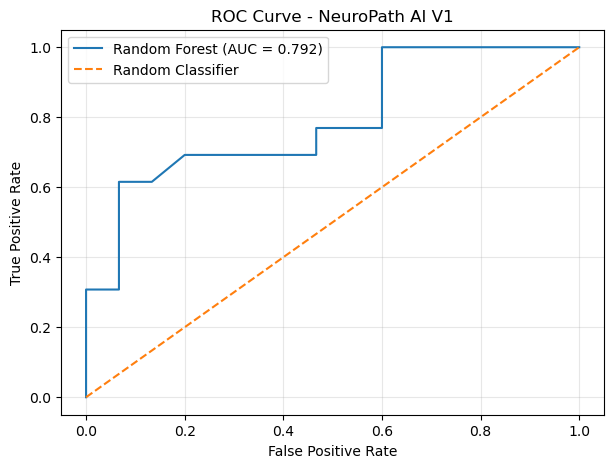

In [107]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

auc = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - NeuroPath AI V1")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [110]:
# Get the trained Random Forest from our pipeline
rf_model = rf_pipeline.named_steps["model"]

# Get the feature names after preprocessing
feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get feature importance values
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df

,Feature,Importance
3,num__MMSE,0.386649
5,num__nWBV,0.155356
4,num__eTIV,0.128546
0,num__Age,0.112706
1,num__EDUC,0.097243
2,num__SES,0.047976
7,cat__M/F_M,0.038951
6,cat__M/F_F,0.032574


In [111]:
import joblib
import os

os.makedirs("../model", exist_ok=True)

joblib.dump(
    rf_pipeline,
    "../model/neuropath_rf_v1.pkl"
)

['../model/neuropath_rf_v1.pkl']

In [112]:
loaded_model = joblib.load(
    "../model/neuropath_rf_v1.pkl"
)

loaded_predictions = loaded_model.predict(X_test)

print("Same predictions:",
      np.array_equal(y_pred_rf, loaded_predictions))

Same predictions: True
